# Manuscript Figure 6

Consider dependence of main trade-off curves on benefit function parameters

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
warnings.simplefilter("ignore") # Best to comment this out during development

colour_set = ['#398564', '#fc3468', '#107dac', '#c68642', '#800080']

# Import lightening function

From: https://gist.github.com/ihincks/6a420b599f43fcd7dbd79d56798c4e5a

In [111]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.
    
    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = np.array(colorsys.rgb_to_hls(*mc.to_rgb(c)))
    return colorsys.hls_to_rgb(c[0],1-amount * (1-c[1]),c[2])

# Model parameters

In [112]:
# Parameters for all figures
maxmeanlink = 20
gamma = 1

In [113]:
meanlink_range = np.arange(0.1, maxmeanlink, 0.1)
meanlink_nreg_range = np.arange(0, maxmeanlink+1)
meanlink_geom_range = np.arange(1, maxmeanlink, 0.1)

# Benefit functions (Hill functions and distributions on them)

In [114]:
def benefit_FOM(x, alpha, b, n50):
    B = (b * (x**alpha)) / ( (x**alpha) + (n50**alpha) )
    return B

def benefit_MOF_poisdist(x, bff):
    poisdist = st.poisson(mu = x)
    maxdeg = poisdist.isf(1e-9)
    netdeg = np.arange(0, maxdeg)
    pk = poisdist.pmf(k = netdeg)
    return np.sum( pk * bff(netdeg) )

def benefit_MOF_geomdist(x, bff):
    geomdist = st.geom(p = 1./x)
    maxdeg = geomdist.isf(1e-5)
    netdeg = np.arange(0, maxdeg)
    pk = geomdist.pmf(k = netdeg)
    return np.sum( pk * bff(netdeg) )

# Cost functions derived from pairwise model

In [115]:
def cost_func_MF(x, tau, gamma):
    cost_MF = 1 - gamma / (x * tau)
    cost_MF[x < gamma/tau] = 0
    return cost_MF

def cost_func_ER(x, tau, gamma):
    cost_ER = (1/2)*( x + 1 - ( 4*gamma/tau + (x-1)**2 )**(1/2) )
    cost_ER[x < gamma/tau] = 0
    return cost_ER
    
def cost_func_nreg(x, tau, gamma):
    cost_nreg = x* ( gamma - tau*(x-1) )/( gamma - x*tau*(x-1) )
    cost_nreg[x < gamma/tau+1] = 0
    return cost_nreg
    
def cost_func_geom(x, tau, gamma):
    numer_geom = -gamma*(x-2) - tau*(x**2-1) + (x-1)*( 4*gamma*tau*(x-1)+tau**2*(x-1)**2 )**(1/2)
    denom_geom = gamma*(x-2)**2 - 2*x*tau*(x-1)
    cost_geom = x*numer_geom / denom_geom
    cost_geom[x < gamma/(2*tau)+1] = 0
    return cost_geom

# Figure 6: Sensitivity to benefit function parameters

In [116]:
# Parameter ranges
alran = np.array([12, 6, 24])
bran = np.array([1.1, 0.7, 1.5])
n50ran = np.array([2, 1.5, 3])
tauran = np.array([0.50, 0.25, 1.0])
ll = np.array([1.0, 0.5, 1.5])

## Figure 6a - ER Network

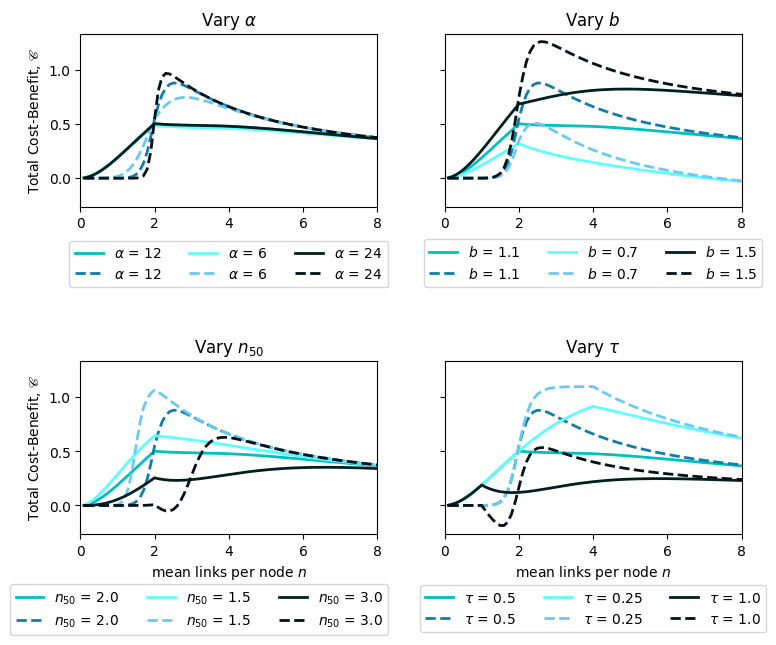

In [139]:
fig, ax = plt.subplots(2, 2, figsize=(8, 7), sharey=True)

ax_pois = np.ravel(ax)[0]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[j], bran[0], n50ran[0])
    MOF_pois_range = np.zeros(len(meanlink_range))
    for i in range(len(meanlink_range)):
        MOF_pois_range[i] = benefit_MOF_poisdist(meanlink_range[i],bf)
    ax_pois.plot(meanlink_range,
                 MOF_pois_range - cost_func_ER(meanlink_range, tauran[0], gamma),
                 color=lighten_color('c',ll[j]), linewidth=2, label=r'$\alpha$ = ' + str(alran[j]))
    ax_pois.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_ER(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linestyle='--', linewidth=2, label=r'$\alpha$ = ' + str(alran[j]))
ax_pois.legend(ncol=3, bbox_to_anchor=(0.50,-0.50), loc='lower center')
ax_pois.set_ylabel('Total Cost-Benefit, $\mathscr{C}$')
ax_pois.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_pois.set_xlim([0, 8])
ax_pois.set_title(r'Vary $\alpha$')

ax_pois = np.ravel(ax)[1]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[j], n50ran[0])
    MOF_pois_range = np.zeros(len(meanlink_range))
    for i in range(len(meanlink_range)):
        MOF_pois_range[i] = benefit_MOF_poisdist(meanlink_range[i],bf)
    ax_pois.plot(meanlink_range,
                 MOF_pois_range - cost_func_ER(meanlink_range, tauran[0], gamma),
                 color=lighten_color('c',ll[j]), linewidth=2, label=r'$b$ = ' + str(bran[j]))
    ax_pois.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_ER(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linestyle='--', linewidth=2, label=r'$b$ = ' + str(bran[j]))
ax_pois.legend(ncol=3, bbox_to_anchor=(0.50,-0.50), loc='lower center')
ax_pois.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_pois.set_xlim([0, 8])
ax_pois.set_title(r'Vary $b$')

ax_pois = np.ravel(ax)[2]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[0], n50ran[j])
    MOF_pois_range = np.zeros(len(meanlink_range))
    for i in range(len(meanlink_range)):
        MOF_pois_range[i] = benefit_MOF_poisdist(meanlink_range[i],bf)
    ax_pois.plot(meanlink_range,
                 MOF_pois_range - cost_func_ER(meanlink_range, tauran[0], gamma),
                 color=lighten_color('c', ll[j]), linewidth=2, label=r'$n_{50}$ = ' + str(n50ran[j]))
    ax_pois.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_ER(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linestyle='--', linewidth=2, label=r'$n_{50}$ = ' + str(n50ran[j]))
ax_pois.legend(ncol=3, bbox_to_anchor=(0.40,-0.62), loc='lower center')
ax_pois.set_ylabel('Total Cost-Benefit, $\mathscr{C}$')
ax_pois.set_xlabel(r'mean links per node $n$')
ax_pois.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_pois.set_xlim([0, 8])
ax_pois.set_title(r'Vary $n_{50}$')

ax_pois = np.ravel(ax)[3]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[0], n50ran[0])
    MOF_pois_range = np.zeros(len(meanlink_range))
    for i in range(len(meanlink_range)):
        MOF_pois_range[i] = benefit_MOF_poisdist(meanlink_range[i],bf)
    ax_pois.plot(meanlink_range,
                 MOF_pois_range - cost_func_ER(meanlink_range, tauran[j], gamma),
                 color=lighten_color('c', ll[j]), linewidth=2, label=r'$\tau$ = ' + str(tauran[j]))
    ax_pois.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_ER(meanlink_range, tauran[j], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linestyle='--', linewidth=2, label=r'$\tau$ = ' + str(tauran[j]))
ax_pois.legend(ncol=3, bbox_to_anchor=(0.50,-0.60), loc='lower center')
ax_pois.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_pois.set_xlabel(r'mean links per node $n$')
ax_pois.set_xlim([0, 8])
ax_pois.set_title(r'Vary $\tau$')
plt.tight_layout()

## Figure 6b - Regular Network

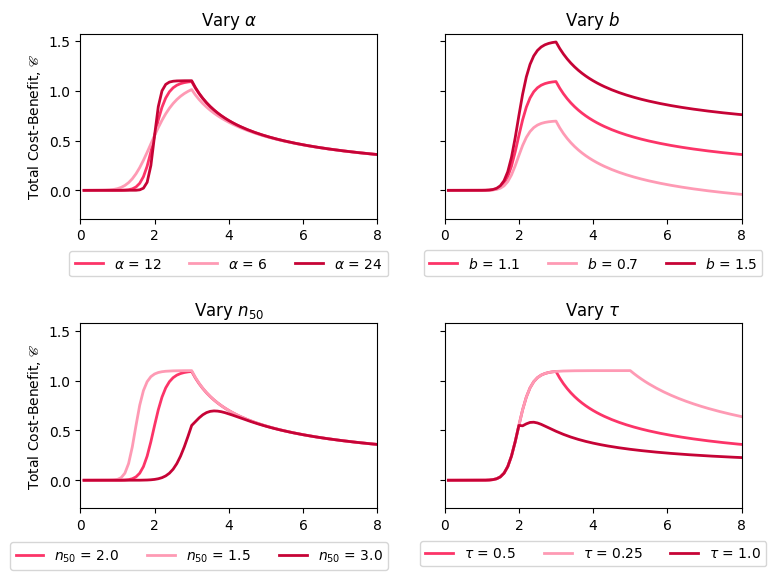

In [150]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6), sharey=True)

ax_nreg = np.ravel(ax)[0]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[j], bran[0], n50ran[0])
    # ax_nreg.plot(meanlink_range,
    #              bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[0], gamma),
    #              color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$\alpha$ = ' + str(alran[j]))
    ax_nreg.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='-', linewidth=2, label=r'$\alpha$ = ' + str(alran[j]))
#ax_nreg.legend(ncol=3, bbox_to_anchor=(0.50,-0.50), loc='lower center')
ax_nreg.legend(ncol=3, bbox_to_anchor=(0.50,-0.35), loc='lower center')
ax_nreg.set_ylabel('Total Cost-Benefit, $\mathscr{C}$')
ax_nreg.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_nreg.set_xlim([0, 8])
ax_nreg.set_title(r'Vary $\alpha$')

ax_nreg = np.ravel(ax)[1]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[j], n50ran[0])
    # ax_nreg.plot(meanlink_range,
    #              bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[0], gamma),
    #              color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$b$ = ' + str(bran[j]))
    ax_nreg.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='-', linewidth=2, label=r'$b$ = ' + str(bran[j]))
#ax_nreg.legend(ncol=3, bbox_to_anchor=(0.50,-0.50), loc='lower center')
ax_nreg.legend(ncol=3, bbox_to_anchor=(0.50,-0.35), loc='lower center')
ax_nreg.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_nreg.set_xlim([0, 8])
ax_nreg.set_title(r'Vary $b$')

ax_nreg = np.ravel(ax)[2]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[0], n50ran[j])
    # ax_nreg.plot(meanlink_range,
    #              bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[0], gamma),
    #              color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$n_{50}$ = ' + str(n50ran[j]))
    ax_nreg.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='-', linewidth=2, label=r'$n_{50}$ = ' + str(n50ran[j]))
ax_nreg.legend(ncol=3, bbox_to_anchor=(0.40,-0.37), loc='lower center')
ax_nreg.set_ylabel('Total Cost-Benefit, $\mathscr{C}$')
ax_nreg.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_nreg.set_xlim([0, 8])
ax_nreg.set_title(r'Vary $n_{50}$')

ax_nreg = np.ravel(ax)[3]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[0], n50ran[0])
    # ax_nreg.plot(meanlink_range,
    #              bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[j], gamma),
    #              color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$\tau$ = ' + str(tauran[j]))
    ax_nreg.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_nreg(meanlink_range, tauran[j], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='-', linewidth=2, label=r'$\tau$ = ' + str(tauran[j]))
ax_nreg.legend(ncol=3, bbox_to_anchor=(0.50,-0.35), loc='lower center')
ax_nreg.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_nreg.set_xlim([0, 8])
ax_nreg.set_title(r'Vary $\tau$')
plt.tight_layout()

## Figure 6c - Geometric Degree Distribution Network

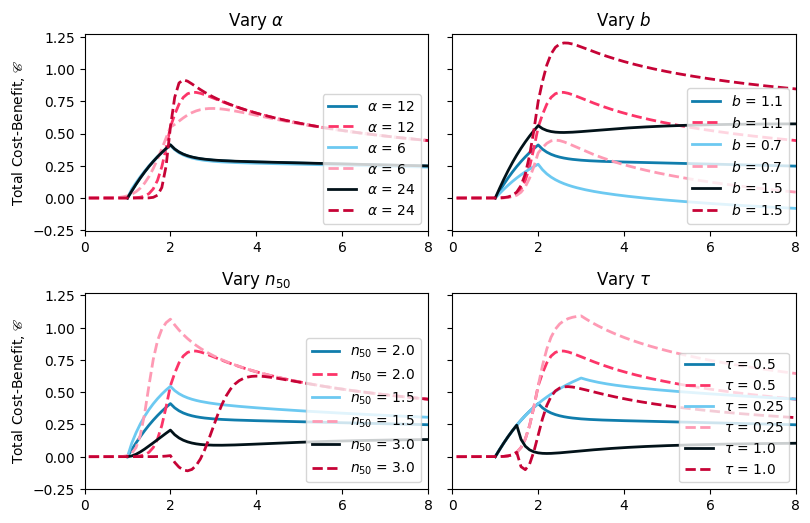

In [119]:
fig, ax = plt.subplots(2, 2, figsize=(8, 16/3), sharey=True)

ax_geom = np.ravel(ax)[0]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[j], bran[0], n50ran[0])
    MOF_geom_range = np.zeros(len(meanlink_geom_range))
    for i in range(len(meanlink_geom_range)):
        MOF_geom_range[i] = benefit_MOF_geomdist(meanlink_geom_range[i],bf)
    ax_geom.plot(meanlink_geom_range,
                 MOF_geom_range - cost_func_geom(meanlink_geom_range, tauran[0], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$\alpha$ = ' + str(alran[j]))
    ax_geom.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_geom(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='--', linewidth=2, label=r'$\alpha$ = ' + str(alran[j]))
ax_geom.legend(loc='lower right')
ax_geom.set_ylabel('Total Cost-Benefit, $\mathscr{C}$')
ax_geom.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_geom.set_xlim([0, 8])
ax_geom.set_title(r'Vary $\alpha$')

ax_geom = np.ravel(ax)[1]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[j], n50ran[0])
    MOF_geom_range = np.zeros(len(meanlink_geom_range))
    for i in range(len(meanlink_geom_range)):
        MOF_geom_range[i] = benefit_MOF_geomdist(meanlink_geom_range[i],bf)
    ax_geom.plot(meanlink_geom_range,
                 MOF_geom_range - cost_func_geom(meanlink_geom_range, tauran[0], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$b$ = ' + str(bran[j]))
    ax_geom.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_geom(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='--', linewidth=2, label=r'$b$ = ' + str(bran[j]))
ax_geom.legend(loc='lower right')
ax_geom.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_geom.set_xlim([0, 8])
ax_geom.set_title(r'Vary $b$')

ax_geom = np.ravel(ax)[2]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[0], n50ran[j])
    MOF_geom_range = np.zeros(len(meanlink_geom_range))
    for i in range(len(meanlink_geom_range)):
        MOF_geom_range[i] = benefit_MOF_geomdist(meanlink_geom_range[i],bf)
    ax_geom.plot(meanlink_geom_range,
                 MOF_geom_range - cost_func_geom(meanlink_geom_range, tauran[0], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$n_{50}$ = ' + str(n50ran[j]))
    ax_geom.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_geom(meanlink_range, tauran[0], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='--', linewidth=2, label=r'$n_{50}$ = ' + str(n50ran[j]))
ax_geom.legend(loc='lower right')
ax_geom.set_ylabel('Total Cost-Benefit, $\mathscr{C}$')
ax_geom.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_geom.set_xlim([0, 8])
ax_geom.set_title(r'Vary $n_{50}$')

ax_geom = np.ravel(ax)[3]
for j in range(0,3):
    bf = lambda x: benefit_FOM(x, alran[0], bran[0], n50ran[0])
    MOF_geom_range = np.zeros(len(meanlink_geom_range))
    for i in range(len(meanlink_geom_range)):
        MOF_geom_range[i] = benefit_MOF_geomdist(meanlink_geom_range[i],bf)
    ax_geom.plot(meanlink_geom_range,
                 MOF_geom_range - cost_func_geom(meanlink_geom_range, tauran[j], gamma),
                 color=lighten_color(colour_set[2],ll[j]), linewidth=2, label=r'$\tau$ = ' + str(tauran[j]))
    ax_geom.plot(meanlink_range,
                 bf(meanlink_range) - cost_func_geom(meanlink_range, tauran[j], gamma),
                 color=lighten_color(colour_set[1],ll[j]), linestyle='--', linewidth=2, label=r'$\tau$ = ' + str(tauran[j]))
ax_geom.legend(loc='lower right')
ax_geom.set_xticks(np.arange(0, maxmeanlink+1, 2))
ax_geom.set_xlim([0, 8])
ax_geom.set_title(r'Vary $\tau$')
plt.tight_layout()